In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import zarr
import yaml
from modules.grid_search.adapters import LRUAdapter
from modules.utils import OFDMConfig, load_ofdm_dataset

In [22]:
ZARR_PATH = Path("/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/prime_coast_dc0.05A_fmin1e+06_fmax7.6e+06_20260724_2101.zarr")
_, _, ofdm_cnfg = load_ofdm_dataset(ZARR_PATH, device="cpu")
sampling_rate = ofdm_cnfg.baseband_sampling_rate
delta_t = 1 / sampling_rate
print(f"Sampling Rate {sampling_rate: g}")


Sampling Rate  6.08e+07


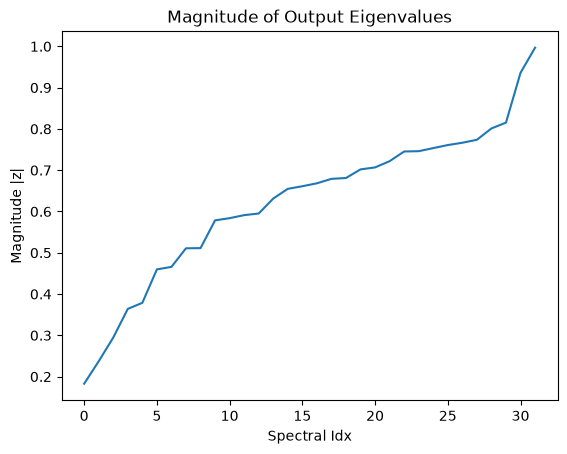

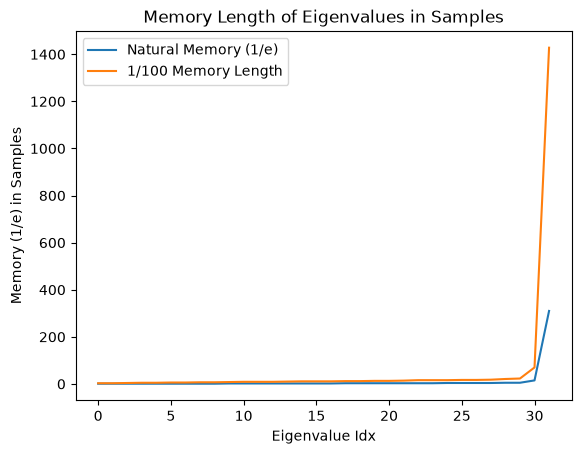

In [ ]:
CHANNEL_MODEL_PATH = Path(r"/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/experiments/train_and_validate/rich_arc_channel_models_20260805_1458")

def _read_jsonl(path: Path):
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]

def _load_channel_runs(channel_dir: Path) -> list[dict]:
    rows = _read_jsonl(channel_dir / 'runs.jsonl')
    for r in rows:
        dist = r.get("distribution")
        r['is_prob'] = dist == 'gaussian'
        r['is_tcn'] = r.get('model') == 'tcn'
    return rows

runs = _load_channel_runs(CHANNEL_MODEL_PATH)

lrus = [run for run in runs if run.get('model') == 'lru']

def _get_best_val(runs: list[dict], perf_key: str) -> dict:
    validation_losses = [run[perf_key] for run in runs]
    best_idx = np.argmin(validation_losses)
    return runs[best_idx]

best_lru_entry = _get_best_val(lrus, "val_per_burst_rrmse_pct")
run_dir = CHANNEL_MODEL_PATH / "runs" / best_lru_entry['run_id']
with open(run_dir / 'config.yaml') as f:
    cfg = yaml.safe_load(f)
    params = cfg['params']
best_lru = LRUAdapter.load(params, run_dir / 'model.pt', device='cpu')

nu_log = torch.cat([b.lru.nu_log    for b in best_lru.model.blocks])
theta_log = torch.cat([b.lru.theta_log for b in best_lru.model.blocks])
diag_lambda = torch.exp(-torch.exp(nu_log) + 1j * torch.exp(theta_log))

# best_lru_final_block = best_lru.model.blocks[-1] 
# best_lru_nu_log = best_lru_final_block.lru.nu_log
# best_lru_theta_log = best_lru_final_block.lru.theta_log
# diag_lambda = torch.exp(-torch.exp(best_lru_nu_log) + 1j * torch.exp(best_lru_theta_log))


mag_diag_lambda = torch.abs(diag_lambda).detach().numpy()

mag_diag_lambda.sort()

plt.title("Magnitude of Output Eigenvalues")
plt.plot(mag_diag_lambda)
plt.xlabel("Spectral Idx")
plt.ylabel("Magnitude |z|")
plt.show()


def memory_length_samples(mag, base):
    assert mag <= 1
    return round(-np.log(base) / (np.log(mag)))

natural_memory_lengths = np.vectorize(memory_length_samples)(mag_diag_lambda, base=np.e)

one_percent_memory_lengths = np.vectorize(memory_length_samples)(mag_diag_lambda, base=100)

plt.title("Memory Length of Eigenvalues in Samples")
plt.xlabel("Eigenvalue Idx")
plt.ylabel("Memory (1/e) in Samples")
plt.plot(natural_memory_lengths, label="Natural Memory (1/e)")
plt.plot(one_percent_memory_lengths, label="1/100 Memory Length")
plt.legend()
plt.show()

In [24]:
natural_memory_lengths

array([  1,   1,   1,   1,   1,   1,   1,   1,   1,   2,   2,   2,   2,
         2,   2,   2,   2,   3,   3,   3,   3,   3,   3,   3,   4,   4,
         4,   4,   5,   5,  15, 310])

In [25]:
one_percent_memory_lengths

array([   3,    3,    4,    5,    5,    6,    6,    7,    7,    8,    9,
          9,    9,   10,   11,   11,   11,   12,   12,   13,   13,   14,
         16,   16,   16,   17,   17,   18,   21,   23,   70, 1428])

In [27]:
print(f"Baseband fft length {ofdm_cnfg.baseband_fft_length}")
print(f"OFDM symbol length {ofdm_cnfg.baseband_ofdm_symbol_length}")

Baseband fft length 608
OFDM symbol length 760
